**Convolutional Autoencoders**

In this lab, you will use convolution layers to build your autoencoder. This usually leads to better results than dense networks and you will see it in action with the [Fashion MNIST dataset](https://www.tensorflow.org/datasets/catalog/fashion_mnist).

## Imports

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

import numpy as np
import matplotlib.pyplot as plt

## Prepare the Dataset

Load the train and test sets from TFDS. Notice that we don't flatten the image. That's because we will be using convolutional layers later that can deal with 2D images.

In [ ]:
def map_image(image, label):
  '''Normalizes the image. Returns image as input and label.'''
  image = tf.cast(image, dtype=tf.float32)
  image = image / 255.0

  return image, image

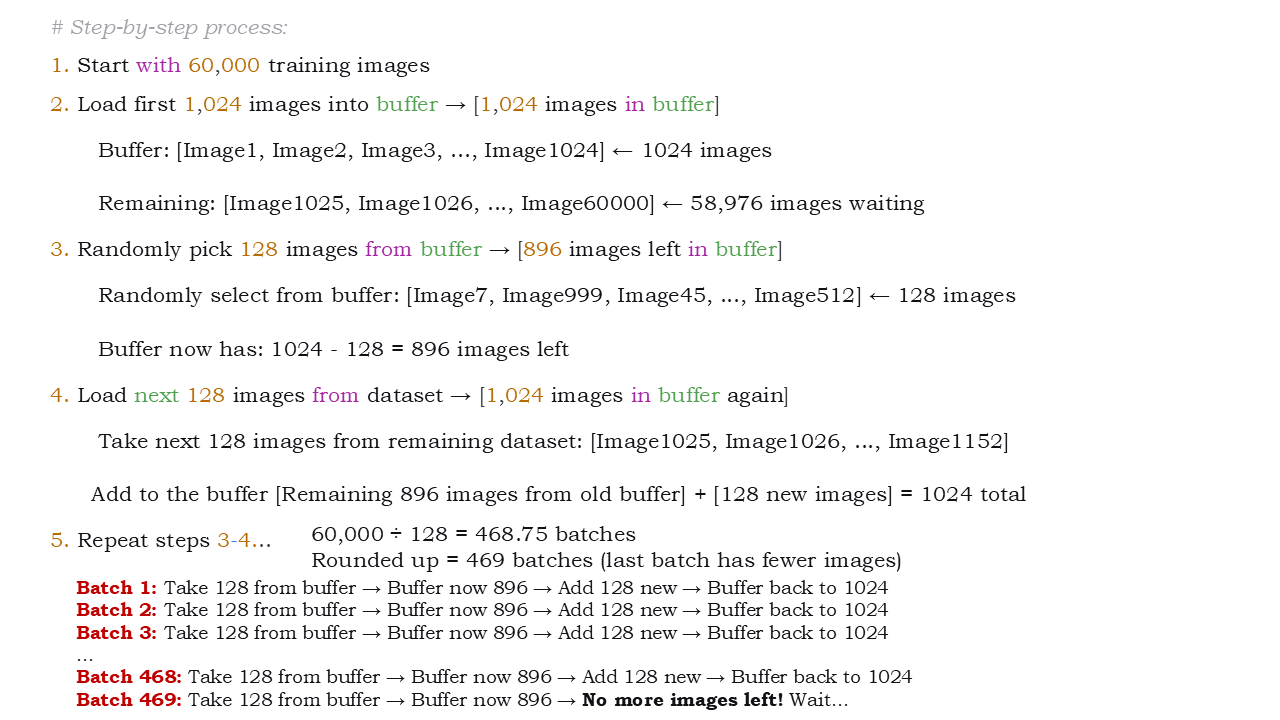

In [ ]:
BATCH_SIZE = 128
SHUFFLE_BUFFER_SIZE = 1024

train_dataset = tfds.load('fashion_mnist', as_supervised=True, split="train")
train_dataset = train_dataset.map(map_image)
train_dataset = train_dataset.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE).repeat()

test_dataset = tfds.load('fashion_mnist', as_supervised=True, split="test")
test_dataset = test_dataset.map(map_image)
test_dataset = test_dataset.batch(BATCH_SIZE).repeat()

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.KKI3NH_3.0.1/fashion_mnist-train.tfrecord*...:   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.KKI3NH_3.0.1/fashion_mnist-test.tfrecord*...:   0…

Dataset fashion_mnist downloaded and prepared to /root/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.


## Define the Model

As mentioned, you will use convolutional layers to build the model. This is composed of three main parts: encoder, latent space, and decoder. You will follow the configuration shown in the image below.

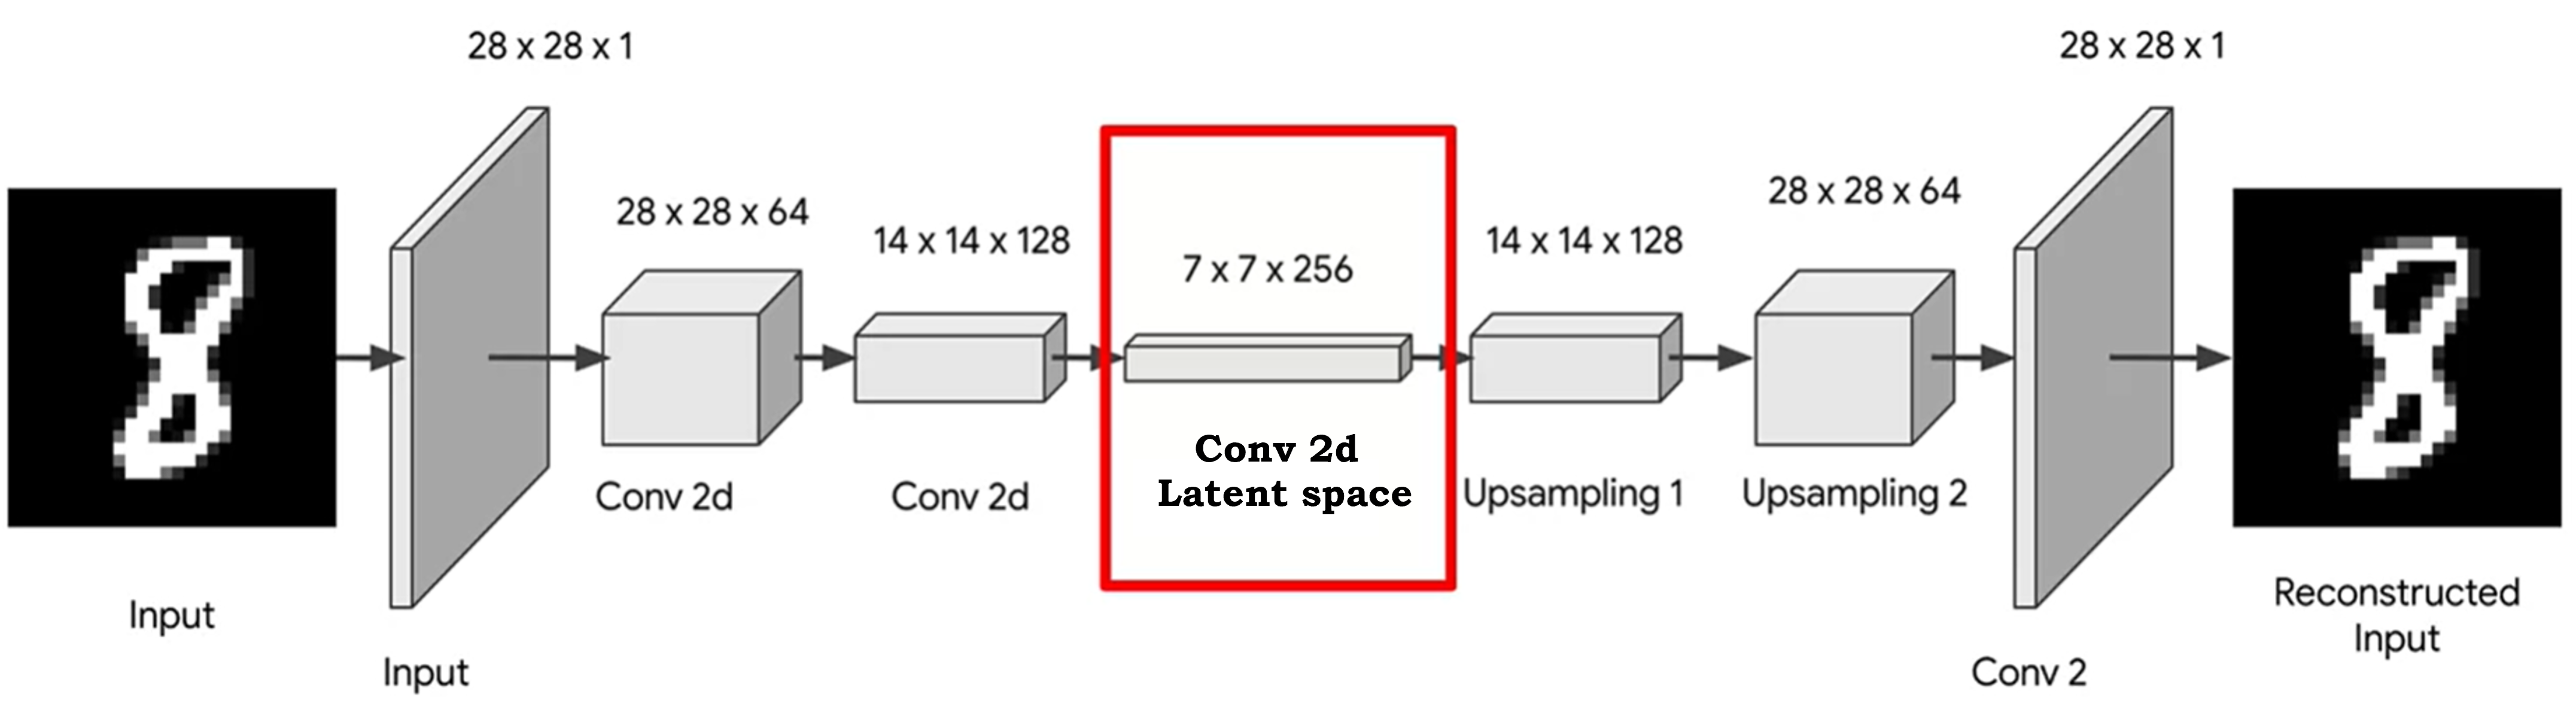

The encoder, just like in previous labs, will contract with each additional layer. The features are generated with the Conv2D layers while the max pooling layers reduce the dimensionality.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

def conv_autoencoder(inputs):
    # ---------------- Encoder ----------------
    enc_conv1 = Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    enc_pool1 = MaxPooling2D((2,2), padding='same')(enc_conv1)      # 14x14x64

    enc_conv2 = Conv2D(128, (3,3), activation='relu', padding='same')(enc_pool1)
    enc_pool2 = MaxPooling2D((2,2), padding='same')(enc_conv2)      # 7x7x128

    # ---------------- Latent Space ----------------
    latent = Conv2D(256, (3,3), activation='relu', padding='same')(enc_pool2)  # 7x7x256

    # ---------------- Decoder ----------------
    dec_up1 = UpSampling2D((2,2))(latent)                           # 14x14x256
    dec_conv1 = Conv2D(128, (3,3), activation='relu', padding='same')(dec_up1)

    dec_up2 = UpSampling2D((2,2))(dec_conv1)                        # 28x28x128
    dec_conv2 = Conv2D(64, (3,3), activation='relu', padding='same')(dec_up2)

    reconstruction = Conv2D(1, (3,3), activation='sigmoid', padding='same')(dec_conv2)

    return latent, reconstruction

You can now build the full autoencoder using the functions above.

In [ ]:
def build_models():
    """Returns (autoencoder_model, encoder_model)."""
    inputs = Input(shape=(28, 28, 1), name="input_image")
    latent_output, reconstructed_output = conv_autoencoder(inputs)

    autoencoder_model = tf.keras.Model(inputs, reconstructed_output, name="conv_autoencoder")
    encoder_model = tf.keras.Model(inputs, latent_output, name="encoder_model")

    return autoencoder_model, encoder_model

# Create both models
autoencoder_model, encoder_model = build_models()

In [ ]:
autoencoder_model.summary()
encoder_model.summary()

Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,073 (2.82 MB)

 Trainable params: 739,073 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

Model: "encoder_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369,664 (1.41 MB)

 Trainable params: 369,664 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

## Compile and Train the model

In [ ]:
train_steps = 60000 // BATCH_SIZE
valid_steps = 60000 // BATCH_SIZE

autoencoder_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy'
)

conv_model_history = autoencoder_model.fit(
    train_dataset,
    steps_per_epoch=train_steps,
    validation_data=test_dataset,
    validation_steps=valid_steps,
    epochs=1
)

468/468 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - loss: 0.3130 - val_loss: 0.2616


## Display sample results

As usual, let's see some sample results from the trained model.

In [ ]:
def display_one_row(disp_images, offset, shape=(28, 28)):
  '''Display sample outputs in one row.'''
  for idx, test_image in enumerate(disp_images):
    plt.subplot(3, 10, offset + idx + 1)
    plt.xticks([])
    plt.yticks([])
    test_image = np.reshape(test_image, shape)
    plt.imshow(test_image, cmap='gray')


def display_results(disp_input_images, disp_encoded, disp_predicted, enc_shape=(8,4)):
  '''Displays the input, encoded, and decoded output values.'''
  plt.figure(figsize=(15, 5))
  display_one_row(disp_input_images, 0, shape=(28,28,))
  display_one_row(disp_encoded, 10, shape=enc_shape)
  display_one_row(disp_predicted, 20, shape=(28,28,))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 748ms/step


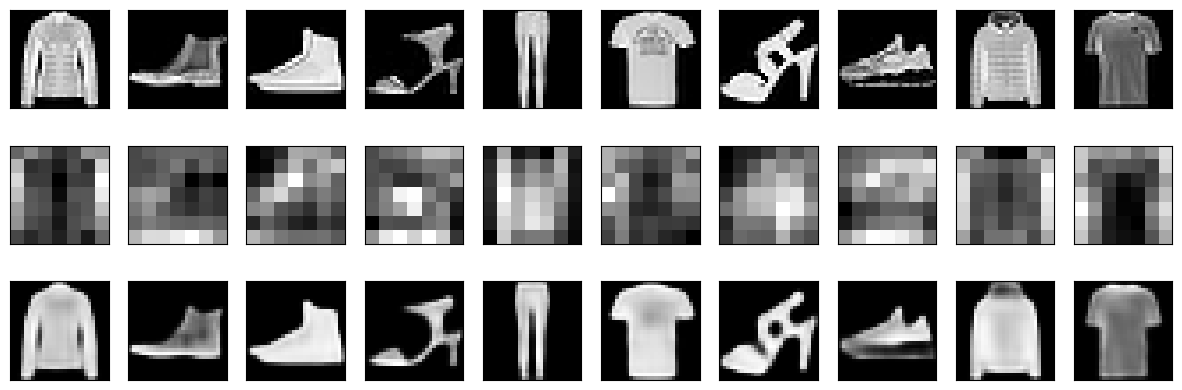

In [ ]:
# take 1 batch of the dataset
test_dataset = test_dataset.take(1)

# take the input images and put them in a list
output_samples = []
for input_image, image in tfds.as_numpy(test_dataset):
      output_samples = input_image

# pick 10 indices
idxs = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# prepare test samples as a batch of 10 images
conv_output_samples = np.array(output_samples[idxs])
conv_output_samples = np.reshape(conv_output_samples, (10, 28, 28, 1))

# get the encoder ouput
encoded = encoder_model.predict(conv_output_samples)
# Reduce the channel dimension of the encoded output for display
encoded_for_display = np.mean(encoded, axis=-1) # Take the mean across the 256 channels

# get a prediction for some values in the dataset
predicted = autoencoder_model.predict(conv_output_samples)

# display the samples, encodings and decoded values!
display_results(conv_output_samples, encoded_for_display, predicted, enc_shape=(7,7))

**Denoising with a CNN Autoencoder**

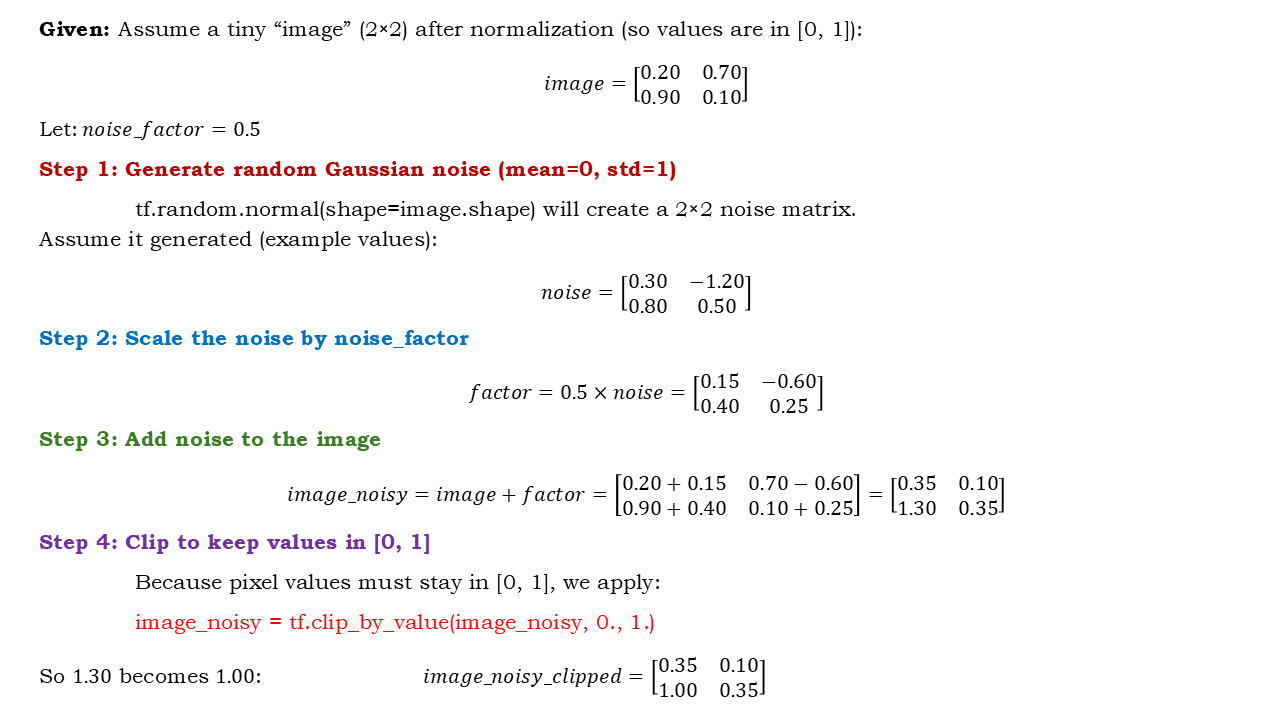

In [ ]:
# prompt: map_image_with_noise

def map_image_with_noise(image, label):
  '''Normalize the images and add random noise.'''
  image = tf.cast(image, tf.float32)
  image = image / 255.0
  noise_factor = 0.5
  factor=noise_factor*tf.random.normal(shape=tf.shape(image))
  # Add random noise
  image_noisy = image + factor
  # Ensure the noisy images are still in the range [0, 1]
  image_noisy = tf.clip_by_value(image_noisy, clip_value_min=0., clip_value_max=1.)
  return image_noisy, image

In [ ]:
BATCH_SIZE = 128
SHUFFLE_BUFFER_SIZE = 1024

train_dataset = tfds.load('fashion_mnist', as_supervised=True, split="train")
train_dataset = train_dataset.map(map_image_with_noise)
train_dataset = train_dataset.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE).repeat()

test_dataset = tfds.load('fashion_mnist', as_supervised=True, split="test")
test_dataset = test_dataset.map(map_image_with_noise)
test_dataset = test_dataset.batch(BATCH_SIZE).repeat()

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

def conv_autoencoder(inputs):
    # ---------------- Encoder ----------------
    enc_conv1 = Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    enc_pool1 = MaxPooling2D((2,2), padding='same')(enc_conv1)      # 14x14x64

    enc_conv2 = Conv2D(128, (3,3), activation='relu', padding='same')(enc_pool1)
    enc_pool2 = MaxPooling2D((2,2), padding='same')(enc_conv2)      # 7x7x128

    # ---------------- Latent Space ----------------
    latent = Conv2D(256, (3,3), activation='relu', padding='same')(enc_pool2)  # 7x7x256

    # ---------------- Decoder ----------------
    dec_up1 = UpSampling2D((2,2))(latent)                           # 14x14x256
    dec_conv1 = Conv2D(128, (3,3), activation='relu', padding='same')(dec_up1)

    dec_up2 = UpSampling2D((2,2))(dec_conv1)                        # 28x28x128
    dec_conv2 = Conv2D(64, (3,3), activation='relu', padding='same')(dec_up2)

    reconstruction = Conv2D(1, (3,3), activation='sigmoid', padding='same')(dec_conv2)

    return latent, reconstruction

In [ ]:
def build_models():
    """Returns (autoencoder_model, encoder_model)."""
    inputs = Input(shape=(28, 28, 1), name="input_image")
    latent_output, reconstructed_output = conv_autoencoder(inputs)

    autoencoder_model = tf.keras.Model(inputs, reconstructed_output, name="conv_autoencoder")
    encoder_model = tf.keras.Model(inputs, latent_output, name="encoder_model")

    return autoencoder_model, encoder_model

# Create both models
autoencoder_model, encoder_model = build_models()

In [ ]:
autoencoder_model.summary()
encoder_model.summary()

Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,073 (2.82 MB)

 Trainable params: 739,073 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

Model: "encoder_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369,664 (1.41 MB)

 Trainable params: 369,664 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
train_steps = 60000 // BATCH_SIZE
valid_steps = 60000 // BATCH_SIZE

autoencoder_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy'
)

conv_model_history = autoencoder_model.fit(
    train_dataset,
    steps_per_epoch=train_steps,
    validation_data=test_dataset,
    validation_steps=valid_steps,
    epochs=1
)

468/468 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - loss: 0.3694 - val_loss: 0.2994


In [ ]:
def display_one_row(disp_images, offset, shape=(28, 28)):
  '''Display sample outputs in one row.'''
  for idx, test_image in enumerate(disp_images):
    plt.subplot(3, 10, offset + idx + 1)
    plt.xticks([])
    plt.yticks([])
    test_image = np.reshape(test_image, shape)
    plt.imshow(test_image, cmap='gray')


def display_results(disp_input_images, disp_encoded, disp_predicted, enc_shape=(8,4)):
  '''Displays the input, encoded, and decoded output values.'''
  plt.figure(figsize=(15, 5))
  display_one_row(disp_input_images, 0, shape=(28,28,))
  display_one_row(disp_encoded, 10, shape=enc_shape)
  display_one_row(disp_predicted, 20, shape=(28,28,))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step


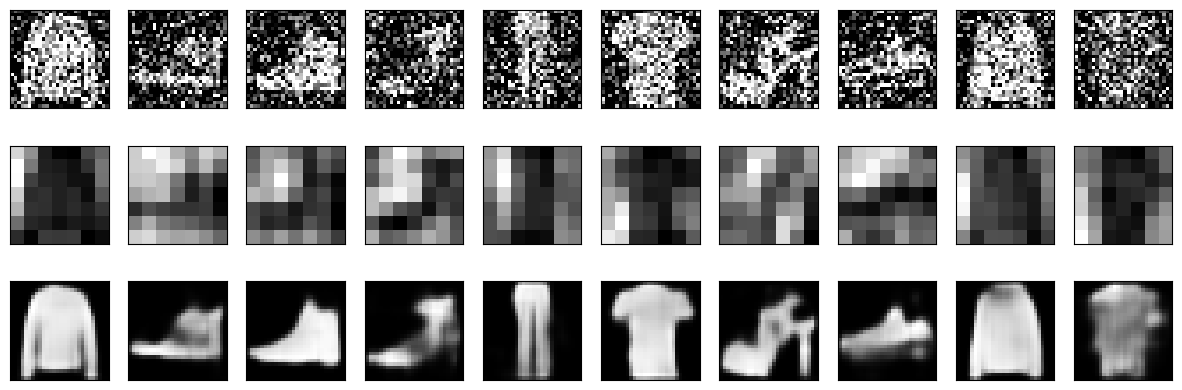

In [ ]:
# take 1 batch of the dataset
test_dataset = test_dataset.take(1)

# take the input images and put them in a list
output_samples = []
for input_image, image in tfds.as_numpy(test_dataset):
      output_samples = input_image

# pick 10 indices
idxs = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# prepare test samples as a batch of 10 images
conv_output_samples = np.array(output_samples[idxs])
conv_output_samples = np.reshape(conv_output_samples, (10, 28, 28, 1))

# get the encoder ouput
encoded = encoder_model.predict(conv_output_samples)
# Reduce the channel dimension of the encoded output for display
encoded_for_display = np.mean(encoded, axis=-1) # Take the mean across the 256 channels

# get a prediction for some values in the dataset
predicted = autoencoder_model.predict(conv_output_samples)

# display the samples, encodings and decoded values!
display_results(conv_output_samples, encoded_for_display, predicted, enc_shape=(7,7))